In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, classification_report
)
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


<class 'pandas.DataFrame'>
RangeIndex: 2007 entries, 0 to 2006
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PetID               2007 non-null   int64  
 1   PetType             2007 non-null   str    
 2   Breed               2007 non-null   str    
 3   AgeMonths           2007 non-null   int64  
 4   Color               2007 non-null   str    
 5   Size                2007 non-null   str    
 6   WeightKg            2007 non-null   float64
 7   Vaccinated          2007 non-null   int64  
 8   HealthCondition     2007 non-null   int64  
 9   TimeInShelterDays   2007 non-null   int64  
 10  AdoptionFee         2007 non-null   int64  
 11  PreviousOwner       2007 non-null   int64  
 12  AdoptionLikelihood  2007 non-null   int64  
dtypes: float64(1), int64(8), str(4)
memory usage: 204.0 KB


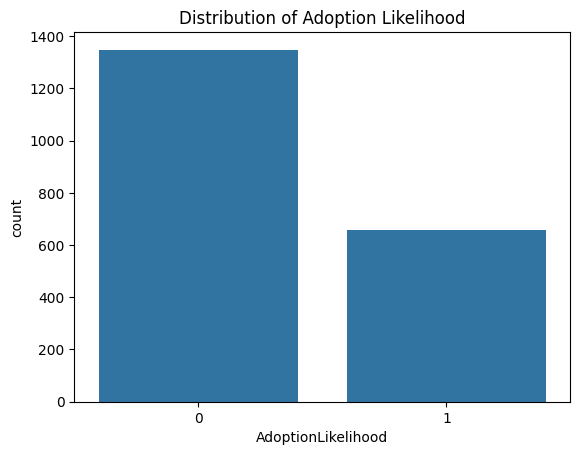

array([1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [2]:
%run EDA.ipynb

zmienne_kategoryczne = ['PetType', 'Breed', 'Color', 'Size']
X_train = pd.get_dummies(X_train, columns=zmienne_kategoryczne, drop_first=True)
X_test = pd.get_dummies(X_test, columns=zmienne_kategoryczne, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


y_train.values.ravel()
y_test.values.ravel()



In [3]:
log_reg = LogisticRegression(max_iter=5000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_base = log_reg.predict(X_test)
y_proba_base = log_reg.predict_proba(X_test)[:, 1]

print('Wyniki modelu bazowego:')
print(classification_report(y_test, y_pred_base))

print('Accuracy:', accuracy_score(y_test, y_pred_base))

# RocCurveDisplay.from_estimator(log_reg, X_test, y_test)
# plt.show()

# cm = confusion_matrix(y_test, y_pred_base)
# ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
# plt.title('Macierz pomyłek modelu bazowego')
# plt.show()

baseline_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_base),
    "recall": recall_score(y_test, y_pred_base),
    "precision": precision_score(y_test, y_pred_base),
    "f1": f1_score(y_test, y_pred_base),
    "auc": roc_auc_score(y_test, y_proba_base)
}


Wyniki modelu bazowego:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       270
           1       0.92      0.71      0.80       132

    accuracy                           0.89       402
   macro avg       0.90      0.84      0.86       402
weighted avg       0.89      0.89      0.88       402

Accuracy: 0.8855721393034826


## Badanie wpływu hiperparametrów

In [ ]:
param_grid = [
    {
        "C": np.logspace(-4, 4, 9),
        "penalty": ["l2"],
        "solver": ["lbfgs", "liblinear", "saga"]
    },
    {
        "C": np.logspace(-4, 4, 9),
        "penalty": ["l1"],
        "solver": ["liblinear", "saga"]
    }
]

grid = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring={
        "recall": "recall",
        "precision": "precision",
        "auc": "roc_auc"
    },
    cv=5,
    refit="precision",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Najlepsze hiperparametry:", grid.best_params_)
print("Najlepszy wynik AUC-ROC w CV:", grid.best_score_)

best_log_reg_model = grid.best_estimator_
y_pred_tuned = best_log_reg_model.predict(X_test)
y_proba_tuned = best_log_reg_model.predict_proba(X_test)[:, 1]

tuned_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "recall": recall_score(y_test, y_pred_tuned),
    "precision": precision_score(y_test, y_pred_tuned),
    "f1": f1_score(y_test, y_pred_tuned),
    "auc": roc_auc_score(y_test, y_proba_tuned)
}



Fitting 5 folds for each of 45 candidates, totalling 225 fits


In [ ]:
#porównanie metryk

labels = list(baseline_metrics.keys())
baseline_vals = list(baseline_metrics.values())
tuned_vals = list(tuned_metrics.values())

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, baseline_vals, width, label="Przed tuningiem")
plt.bar(x + width/2, tuned_vals, width, label="Po tuningu")
plt.xticks(x, labels)
plt.ylabel("Wartość metryki")
plt.title("Porównanie modelu przed i po tuningu")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [ ]:
#wpływ parametru C

results = grid.cv_results_

plt.figure(figsize=(10, 5))

for penalty in ["l1", "l2"]:
    mask = np.array([penalty in p for p in results["param_penalty"]])
    Cs = results["param_C"][mask].data.astype(float)
    recalls = results["mean_test_recall"][mask]

    plt.semilogx(Cs, recalls, marker="o", label=f"penalty={penalty}")

plt.xlabel("C (siła regularyzacji)")
plt.ylabel("Recall (średni z CV)")
plt.title("Wpływ parametru C na recall")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.show()